This notebook sets the hexagonal grids for the park, that the later lidar analysis (and foliage analysis, but that's set up as hex polygons as opposed to centroids) use.

I've begun with a pretty extensive import list, but this will be whittled down as I iterate.

This is a pretty messy back-and-forth as I slowly develop the libraries etc.

Only look at this to understand the background/dev process - please use the example workflow file instead - see here: [notebooks/modularising_the_approach/example_workflow.ipynb](example_workflow.ipynb)

Key references:

- https://www.redblobgames.com/grids/hexagons/
- https://www.ordnancesurvey.co.uk/documents/resources/guide-coordinate-systems-great-britain.pdf

In [237]:
# Import required libraries
import laspy
import rasterio
from rasterio.transform import from_bounds
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.io import MemoryFile
from rasterio.warp import calculate_default_transform, reproject, Resampling
from scipy.interpolate import griddata
from scipy.ndimage import generic_filter
import pdal
import json
from pathlib import Path
import datetime

import rasterio
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.io import MemoryFile

import glob
import os

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, Polygon, MultiPolygon
from shapely.ops import unary_union


In [238]:
from shapely.geometry import box

In [280]:
# for dev work

import sys
import importlib

# Add src to path (do this once at the top)
sys.path.insert(0, '../../src')

# Initial import
import park_vga

# After editing:
importlib.reload(park_vga.defining_grids)
importlib.reload(park_vga)

<module 'park_vga' from '/Users/maeve/Documents/park-vga/notebooks/modularising_the_approach/../../src/park_vga/__init__.py'>

In [281]:
park_vga.example()

hello world!
version 4


In [241]:
# park_gdf= gpd.read_file("../../processed_datasets/Leeds_Woodhouse_Moor_park_boundaries.geojson")
# lidar_dir= "../../example_datasets"
# OUTPUT_DIR = Path("../../outputs/method_03_hex")
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# # Analysis parameters
# GRID_SPACING = 10  # meters between analysis points
# OBSERVER_HEIGHT = 1.0  # meters (eye height)
# MAX_DISTANCE = 100  # maximum visibility distance in meters
# MIN_VEG_AREA = 2  # minimum vegetation polygon area in sq meters

# FILE_NAME = f"Woodhouse_Moor_{GRID_SPACING}_m_grid_hex_buffer"

In [242]:
# "Primary Name": "Woodhouse Moor",

# alternative:
# "id": "LEEDS_24c20c1a69e8;LEEDS_26c1e2aa11e8",

In [243]:
# turning this into a function - will add to module under different name (without test_)

def test_load_data(boundaries_file, name, buffer_distance, type="primary name"):
    # Load park boundaries
    park_gdf = gpd.read_file(boundaries_file)
    
    # Filter for the specific park
    if type == "primary name":
        park_gdf = park_gdf[park_gdf['Primary Name'] == name]
    else:
        park_gdf = park_gdf[park_gdf['id'] == name]
    
    # Create buffer around the park boundary
    park_gdf['geometry'] = park_gdf.geometry.buffer(buffer_distance)
    
    return park_gdf


In [244]:
boundaries_file = "../../example_datasets/Leeds_pp_or_g_cmb.geojson"
primary_name = "Woodhouse Moor"
buffer_distance = 20 # metres

alt_id = "LEEDS_24c20c1a69e8;LEEDS_26c1e2aa11e8"

In [245]:
# now doing it via the module function:

park_gdf = park_vga.load_data(boundaries_file, primary_name, buffer_distance)

In [246]:
# park_gdf = park_vga.load_data(boundaries_file, alt_id, buffer_distance, type="id")

In [247]:
park_gdf.columns

Index(['Name (OS)', 'Other name(s) (OS)', 'Type (OS)', 'OS ID', 'Name (OSM)',
       'Other name(s) (OSM)', 'Type (OSM)', 'OSM ID', 'flag', 'id',
       'Primary Name', 'Other Names', 'Merged Count', 'Total Area (m²)',
       'geometry'],
      dtype='str')

In [248]:
park_gdf.head()

,Name (OS),Other name(s) (OS),Type (OS),OS ID,Name (OSM),Other name(s) (OSM),Type (OSM),OSM ID,flag,id,Primary Name,Other Names,Merged Count,Total Area (m²),geometry
51,NaN,None,Public Park Or Garden,3D6C4AD7-033F-80C3-E063-8ECAA00A8EB3,NaN,NaN,NaN,4002489.0; 224962322.0,OS; OSM,LEEDS_6ddbccbe638c;LEEDS_9866db1f86cb;LEEDS_57...,Woodhouse Moor,Woodhouse Moor Park,3,219143.971209,"POLYGON ((428682.036 434968.572, 428682.682 43..."


EPSG:27700
Bufferred park area: 258751.54042094335
Original park area: 219143.971209261


<Axes: >

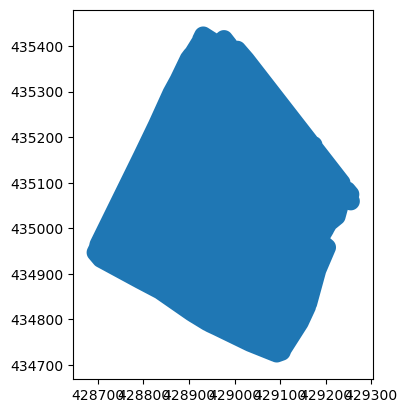

In [249]:
# check that it worked:
print(park_gdf.crs)
print("Bufferred park area:", park_gdf.geometry.iloc[0].area)
print("Original park area:", park_gdf['Total Area (m²)'].iloc[0])
park_gdf.plot()

In [250]:
# Calculate the bounding box and then find the appropriate lidar tile 

bbox_list = list(park_gdf.bounds.iloc[0])

In [251]:
bbox_list

[428675.24753552524, 434705.6015645066, 429274.64295245457, 435442.7927353812]

In [252]:
test_bbox = gpd.GeoSeries(box(*bbox_list), crs="EPSG:27700")

In [253]:
# test_bbox = park_gdf.envelope

In [254]:
def test_easting_northing_to_os_grid(easting, northing, include_quadrant=False):
    """
    Convert easting/northing (British National grid - EPSG:27700) directly to OS grid reference.
    
    Parameters:
    -----------
    easting : float
        Easting in meters (EPSG:27700)
    northing : float
        Northing in meters (EPSG:27700)
    include_quadrant : bool
        If True, returns quadrant (ne, nw, se, sw). If False, returns basic 10km reference.
        
    Returns:
    --------
    str : OS grid reference (e.g., 'SD50' or 'SD50ne')
    """
    
    first_letters = ['S', 'T', 'N', 'O', 'H']
    second_letters = ['V', 'W', 'X', 'Y', 'Z',
                      'Q', 'R', 'S', 'T', 'U',
                      'L', 'M', 'N', 'O', 'P',
                      'F', 'G', 'H', 'J', 'K',
                      'A', 'B', 'C', 'D', 'E']
    
    e_500 = int(easting / 500000)
    n_500 = int(northing / 500000)
    e_100 = int((easting % 500000) / 100000)
    n_100 = int((northing % 500000) / 100000)
    
    try:
        first_letter = first_letters[n_500 * 2 + e_500]
        second_letter = second_letters[n_100 * 5 + e_100]
    except IndexError:
        return None
    
    e_within_100km = (easting % 100000) / 1000
    n_within_100km = (northing % 100000) / 1000
    e_10km = int(e_within_100km / 10)
    n_10km = int(n_within_100km / 10)
    
    grid_ref = f"{first_letter}{second_letter}{e_10km}{n_10km}"
    
    if include_quadrant:
        e_is_east = (e_within_100km % 10) >= 5
        n_is_north = (n_within_100km % 10) >= 5
        quadrant = ('ne' if e_is_east and n_is_north else
                   'se' if e_is_east else
                   'nw' if n_is_north else 'sw')
        grid_ref += quadrant
    
    return grid_ref

In [255]:
def test_get_tile_refs_from_bbox(bbox):
    # get the corner points of the bounding box
    corners = [bbox[0].exterior.coords[i] for i in range(4)]
    # print(corners) # for dev, but remove for scaling up.

    # convert each corner to a grid reference
    grid_refs = [test_easting_northing_to_os_grid(corner[1], corner[0], include_quadrant=True) for corner in corners]
    
    # return unique grid references
    return set(grid_refs)

In [256]:
test_grid_refs = test_get_tile_refs_from_bbox(test_bbox)

In [257]:
test_bbox

0    POLYGON ((429274.643 434705.602, 429274.643 43...
dtype: geometry

In [258]:
print(test_grid_refs)

{'SE32nw', 'SE32ne'}


In [259]:
def test_find_tiles(park_gdf, crs="EPSG:27700"):
    """From bounding park geometry, calculate bounding box and associated grid refs"""
    bbox_list = list(park_gdf.bounds.iloc[0])
    bbox = gpd.GeoSeries(box(*bbox_list), crs=crs)
    grid_refs = test_get_tile_refs_from_bbox(bbox)
    return set(grid_refs)

In [260]:
test_find_tiles(park_gdf)

{'SE32ne', 'SE32nw'}

In [261]:
tile_names = park_vga.find_tiles(park_gdf)

Now we have to do a file path search and match the file path

In [262]:
lidar_dtm = "/Volumes/Extreme SSD/DTM"
lidar_dsm = "/Volumes/Extreme SSD/FZ_DSM"

In [263]:
def test_find_file_paths(tile_names, lidar_dtm, lidar_dsm):
    """Given a set of tile names, find the corresponding file paths for DTM and DSM"""
    dtm_paths = []
    dsm_paths = []
    
    for tile in tile_names:
        dtm_pattern = os.path.join(lidar_dtm, f"*{tile}*.tif")
        dsm_pattern = os.path.join(lidar_dsm, f"*{tile}*.tif")
        
        dtm_files = glob.glob(dtm_pattern)
        dsm_files = glob.glob(dsm_pattern)
        
        if dtm_files:
            dtm_paths.append(dtm_files[0])  # Assuming one file per tile
        else:
            print(f"Warning: No DTM file found for tile {tile}")
        
        if dsm_files:
            dsm_paths.append(dsm_files[0])  # Assuming one file per tile
        else:
            print(f"Warning: No DSM file found for tile {tile}")
    
    return dtm_paths, dsm_paths

In [264]:
test_find_file_paths(tile_names, lidar_dtm, lidar_dsm)

([], [])

In [265]:
def test_park_geometry_to_file_path(park_gdf, lidar_dtm, lidar_dsm):
    tile_names = park_vga.find_tiles(park_gdf)
    dtm_paths, dsm_paths = test_find_file_paths(tile_names, lidar_dtm, lidar_dsm)
    return dtm_paths, dsm_paths

In [266]:
test_park_geometry_to_file_path(park_gdf, lidar_dtm, lidar_dsm)

([], [])

In [267]:
def check_plot(park_gdf):
    park_gdf.plot()

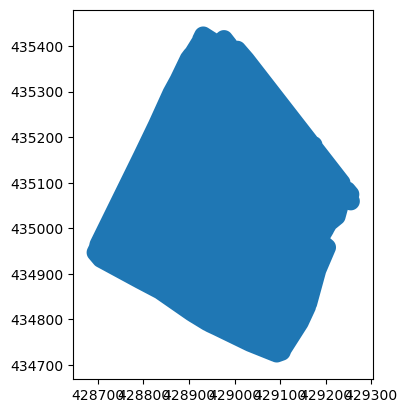

In [268]:
check_plot(park_gdf)

In [269]:
park_vga.park_geometry_to_file_path(park_gdf, lidar_dtm, lidar_dsm)

([], [])

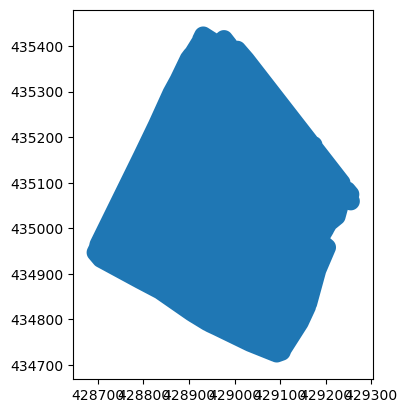

In [270]:
park_vga.check_plot(park_gdf)

Creating a grid across the area

- Will add the lidar loading stuff in the next notebook, I want this one to be mainly configuration
- NB Using british grid for this, for best accuracy when it comes to distance measurements.

In [271]:
spacing= 10  # example spacing in meters
h_spacing = 1.5 * spacing  # Horizontal spacing
v_spacing = spacing * np.sqrt(3) / 2  # Vertical spacing

print(f"Horizontal spacing: {h_spacing} m", f"Vertical spacing: {v_spacing} m")

Horizontal spacing: 15.0 m Vertical spacing: 8.660254037844386 m


In [272]:
def create_hexagon_grid_from_polygons(park_gdf, spacing=10):
    """
    Create hexagonal grid by generating hexagon polygons first,
    then extracting their centroids.
    
    Parameters:
    park_geometry: shapely geometry of park boundary
    spacing: circumradius of each hexagon (distance from center to vertex) in m
    
    Returns:
    GeoDataFrame with hexagon centroids
    """

    park_geometry = park_gdf.geometry.iloc[0]
    bounds = park_geometry.bounds
    
    # Hexagon dimensions
    h_spacing = 1.5 * spacing  # Horizontal spacing
    v_spacing = spacing * np.sqrt(3) / 2  # Vertical spacing
    
    # Create hexagon polygons and collect centroids
    centroids = []
    
    x_min, y_min, x_max, y_max = bounds
    y = y_min
    row = 0
    
    while y <= y_max:
        x = x_min
        if row % 2 == 1:
            x += h_spacing / 2
        
        while x <= x_max:
            # Create hexagon centered at (x, y)
            angles = np.linspace(0, 2*np.pi, 7)
            hex_x = x + spacing * np.cos(angles)
            hex_y = y + spacing * np.sin(angles)
            hexagon = Polygon(list(zip(hex_x, hex_y)))
            
            # Check if hexagon center is in park (or if hexagon intersects)
            if park_geometry.contains(Point(x, y)):
                centroids.append(Point(x, y))
            elif park_geometry.intersects(hexagon):
                # Include if hexagon overlaps park boundary
                centroids.append(Point(x, y))
            
            x += h_spacing
        
        y += v_spacing
        row += 1
    
    grid_gdf = gpd.GeoDataFrame(geometry=centroids, crs='EPSG:27700')
    print(f"Created {len(grid_gdf)} hexagon centers with {spacing}m spacing")
    
    return grid_gdf

In [273]:
grid_gdf = create_hexagon_grid_from_polygons(park_gdf, spacing=10)

Created 2136 hexagon centers with 10m spacing


<Axes: >

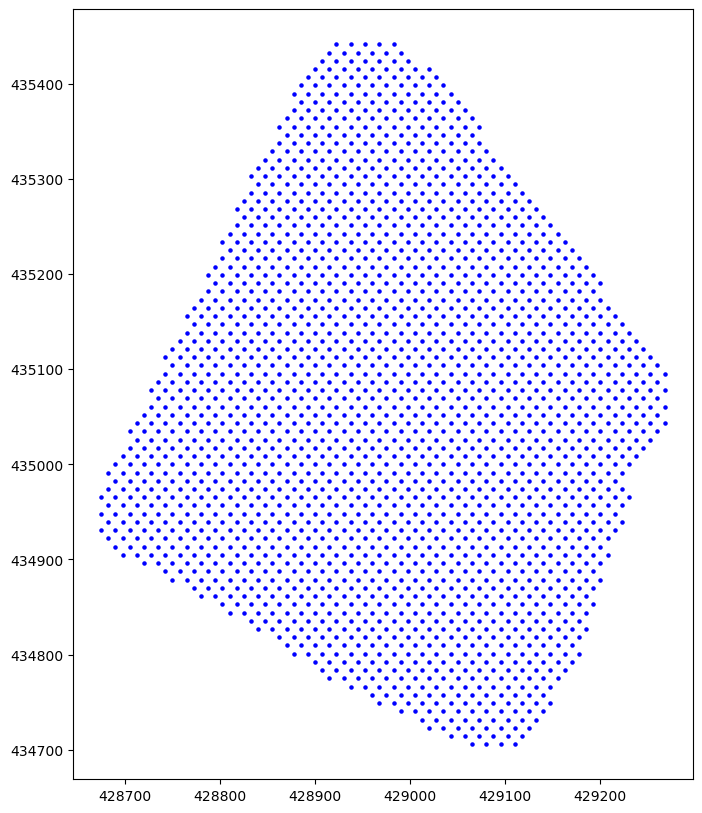

In [274]:
grid_gdf.plot(figsize=(10, 10), markersize=5, color='blue')

In [275]:
def create_hexagon_grid(park_gdf, spacing=10, return_mode='centroids'):
    """
    Create a regular pointy-top hexagonal grid within a park boundary.
    
    Spacing refers to vertical distance between hexagon centroid rows.
    
    Reference: https://www.redblobgames.com/grids/hexagons/
    
    Parameters:
    -----------
    park_gdf : GeoDataFrame
        GeoDataFrame containing the park boundary (EPSG:27700)
    spacing : float
        Vertical distance in meters between adjacent hexagon centroid rows
    return_mode : str
        'centroids' - return GeoDataFrame of centroid points
        'polygons' - return GeoDataFrame of hexagon polygons  
        'both' - return dict with both 'centroids' and 'polygons'
    
    Returns:
    --------
    GeoDataFrame or dict
    """
    
    park_geometry = park_gdf.geometry.iloc[0]
    bounds = park_geometry.bounds
    
    # For pointy-top: vert_spacing = 1.5 × size, so size = spacing / 1.5
    size = spacing / 1.5
    
    # Horizontal spacing (width) = sqrt(3) × size
    h_spacing = np.sqrt(3) * size
    v_spacing = spacing  # = 1.5 × size
    
    # Pointy-top vertices at these angles
    vertex_angles = np.array([30, 90, 150, 210, 270, 330]) * np.pi / 180
    
    # Offset for odd rows: sqrt(3)/2 × size = h_spacing/2
    offset_odd_row = h_spacing / 2
    
    centroids = []
    polygons = []
    
    x_min, y_min, x_max, y_max = bounds
    y = y_min
    row = 0
    
    while y <= y_max:
        x = x_min
        # Offset alternating rows
        if row % 2 == 1:
            x += offset_odd_row
        
        while x <= x_max:
            centroid = Point(x, y)
            
            # Create hexagon polygon
            hex_x = x + size * np.cos(vertex_angles)
            hex_y = y + size * np.sin(vertex_angles)
            hexagon = Polygon(list(zip(hex_x, hex_y)))
            
            # Include if centroid in park or hexagon intersects boundary
            if park_geometry.contains(centroid) or park_geometry.intersects(hexagon):
                centroids.append(centroid)
                polygons.append(hexagon)
            
            x += h_spacing
        
        y += v_spacing
        row += 1
    
    centroids_gdf = gpd.GeoDataFrame(geometry=centroids, crs='EPSG:27700')
    
    if return_mode == 'centroids':
        print(f"Created {len(centroids_gdf)} pointy-top hexagon centroids ({spacing}m vertical spacing)")
        return centroids_gdf
    
    elif return_mode == 'polygons':
        polygons_gdf = gpd.GeoDataFrame(geometry=polygons, crs='EPSG:27700')
        print(f"Created {len(polygons_gdf)} pointy-top hexagon polygons ({spacing}m vertical spacing)")
        return polygons_gdf
    
    elif return_mode == 'both':
        polygons_gdf = gpd.GeoDataFrame(geometry=polygons, crs='EPSG:27700')
        print(f"Created {len(centroids_gdf)} pointy-top hexagons ({spacing}m vertical spacing)")
        return {
            'centroids': centroids_gdf,
            'polygons': polygons_gdf
        }
    
    else:
        raise ValueError(f"return_mode must be 'centroids', 'polygons', or 'both'")

In [276]:
new_grid_gdf = create_hexagon_grid(park_gdf, spacing=10, return_mode='polygons')
new_grid_gdf_2 = create_hexagon_grid(park_gdf, spacing=10, return_mode='centroids')

Created 2349 pointy-top hexagon polygons (10m vertical spacing)
Created 2349 pointy-top hexagon centroids (10m vertical spacing)


<Axes: >

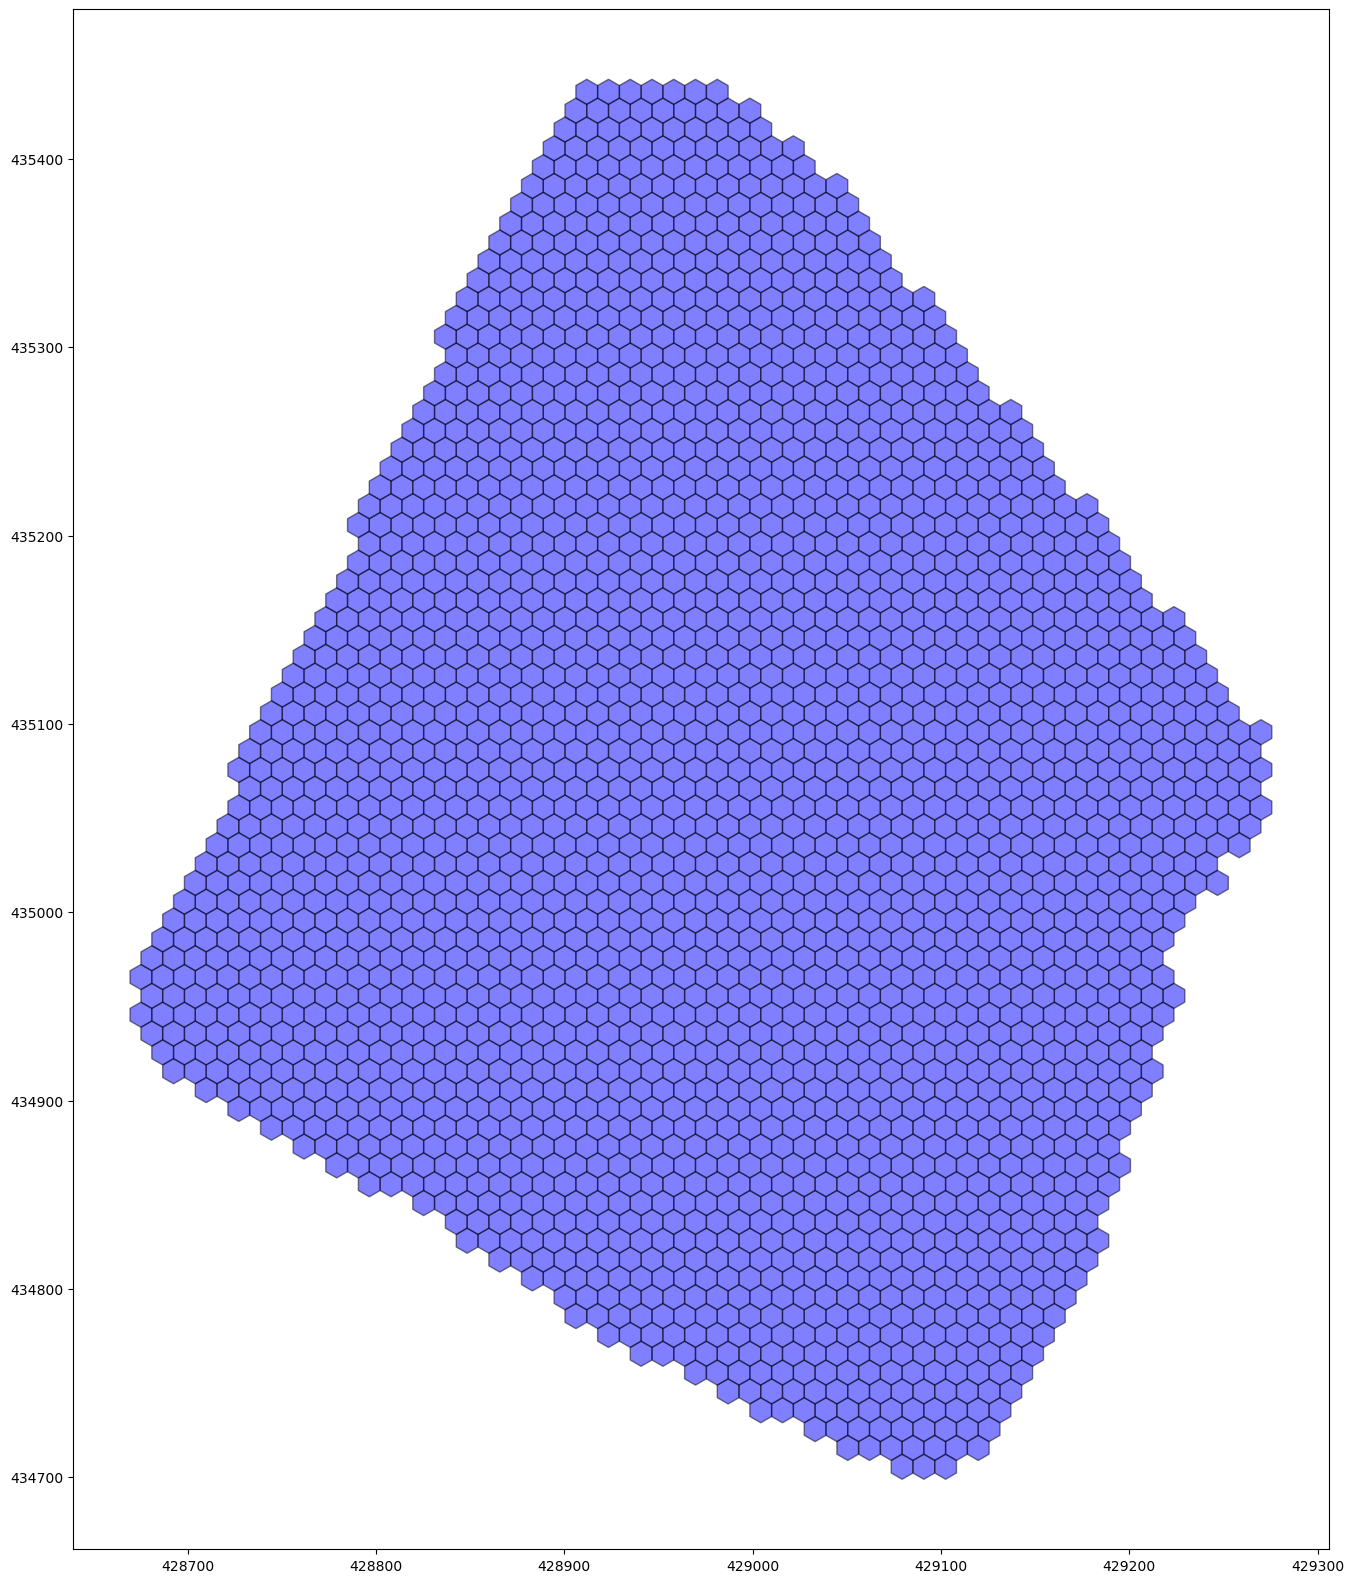

In [277]:
# a close-up/zoom in of a region of the park to check the grid looks right:
new_grid_gdf.plot(figsize=(20, 20), markersize=5, color='blue', edgecolor='black', alpha=0.5, )

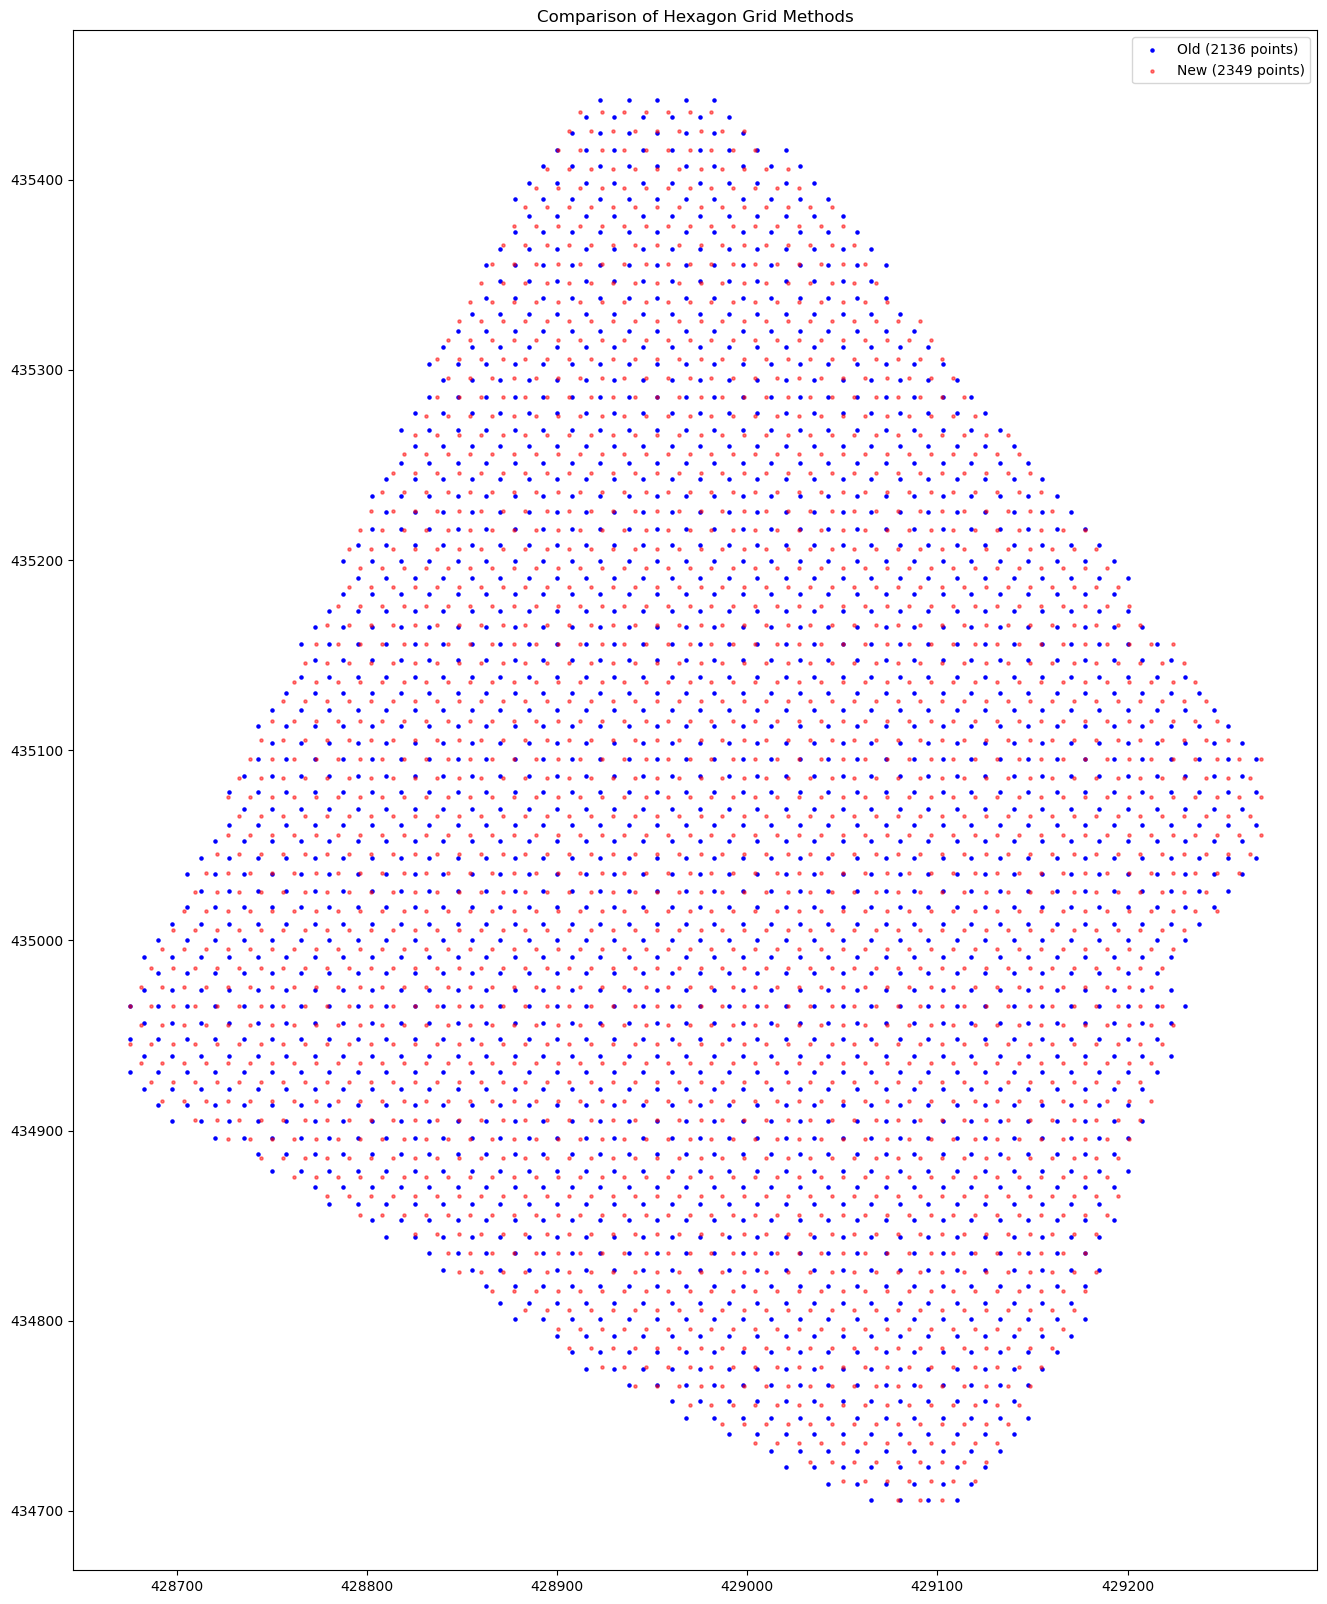

In [278]:
# plotting both versions on top of one another to compare

fig, ax = plt.subplots(figsize=(20, 20))
grid_gdf.plot(ax=ax, markersize=5, color='blue', label=f'Old ({len(grid_gdf)} points)')
new_grid_gdf_2.plot(ax=ax, markersize=5, color='red',alpha=0.5, label=f'New ({len(new_grid_gdf_2)} points)')
plt.legend()
plt.title("Comparison of Hexagon Grid Methods")
plt.show()

Old version: Created 2136 hexagon centers with 10m spacing

New version: Created 2349 pointy-top hexagon polygons (10m vertical spacing)

New version has less vertical stretching: fixed!

Will just add the new one to the module I think - no need to keep the old version.

N.B. - this works with multipolygons too!

In [282]:
results = park_vga.create_hexagon_grid(park_gdf, spacing=10, return_mode='both')

Created 2349 pointy-top hexagons (10m vertical spacing)


<Axes: >

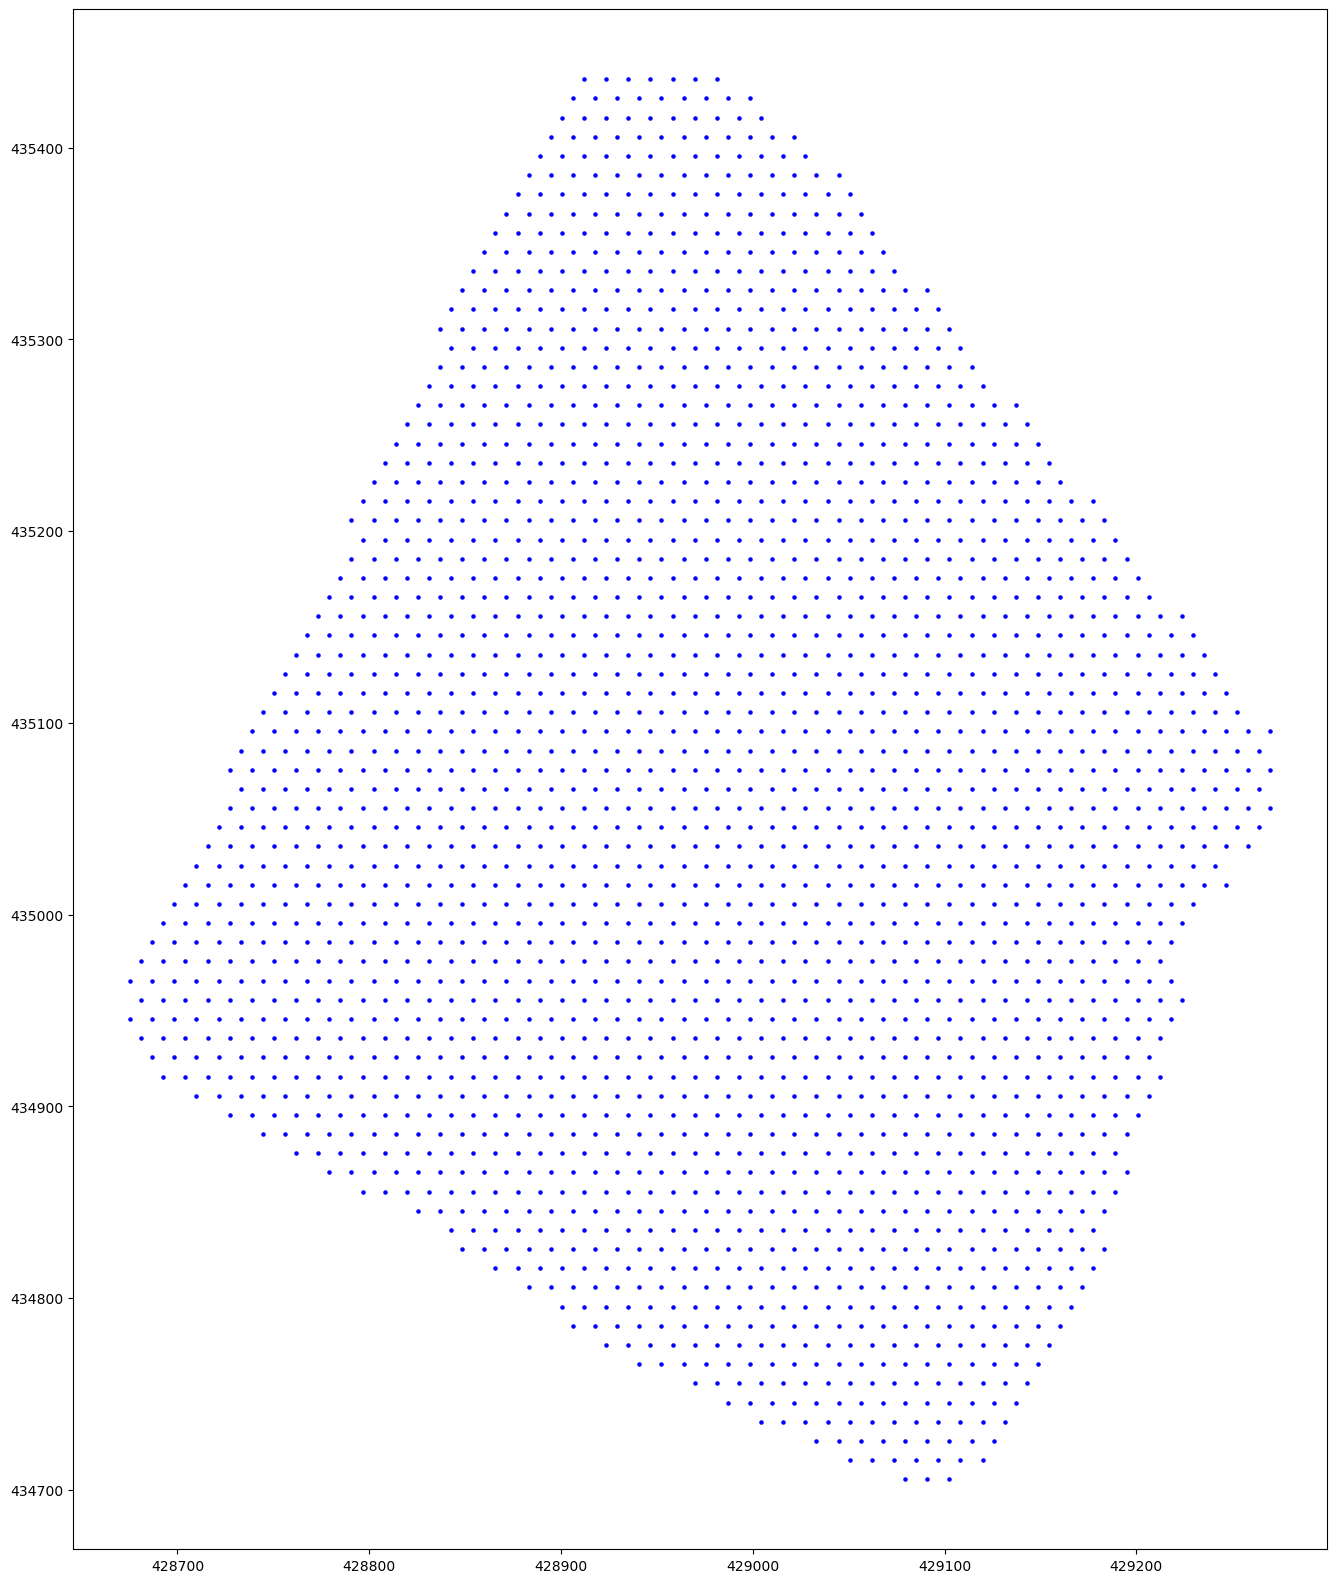

In [284]:
results["centroids"].plot(figsize=(20, 20), markersize=5, color='blue', label='Centroids')

<Axes: >

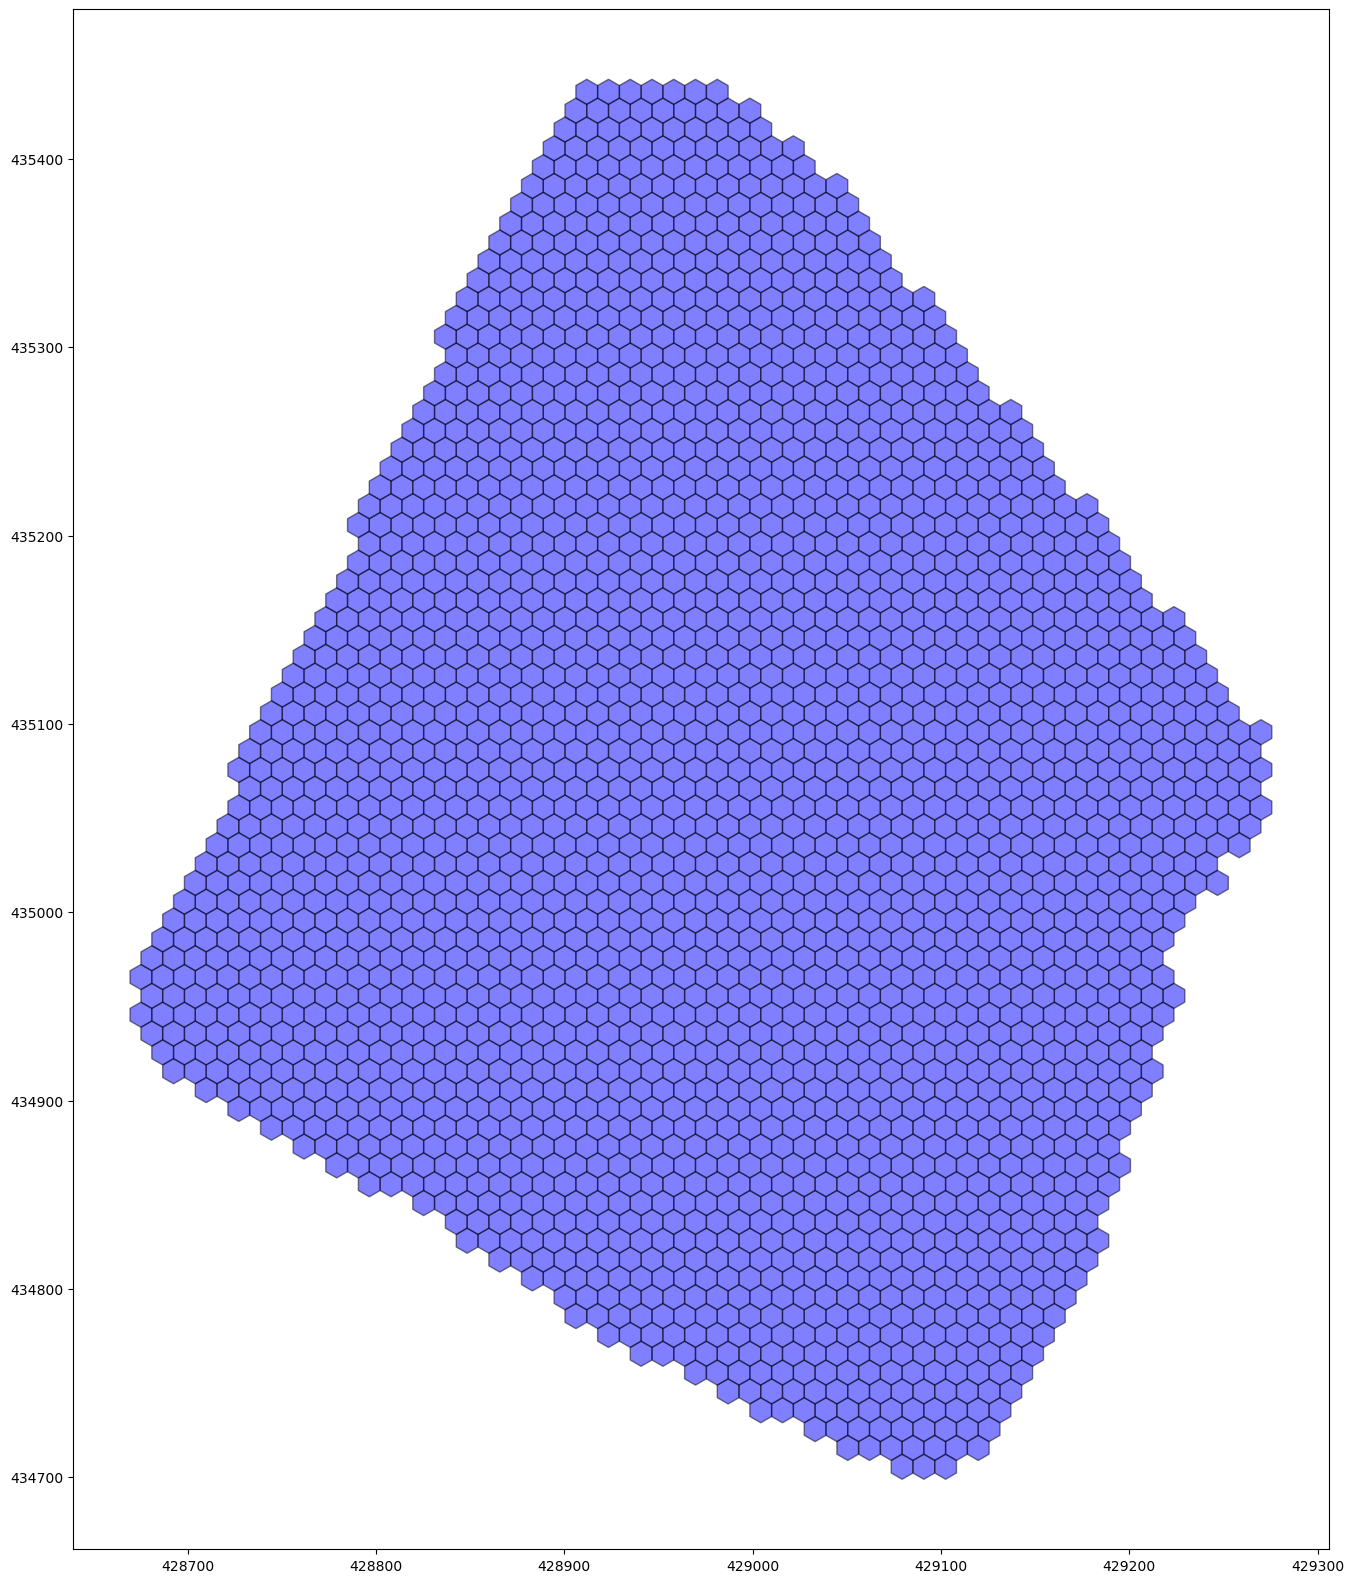

In [286]:
results["polygons"].plot(figsize=(20, 20), edgecolor="black", color='blue', alpha=0.5, label='Polygons')